# Makemore exercises. Part I

## Training trigram model
Train a **trigram** language model, i.e. take two characters as an input to predict the 3rd one. Feel free to use either counting or a neural net. Evaluate the loss; Did it improve over a **bigram** model?

In [1]:
words = open('../data/names.txt', 'r').read().splitlines()
alphabet = sorted(set('.'.join(words)))
letter_to_int_encoding = {s : i for i, s in enumerate(alphabet)}
int_to_letter_encoding = {i : s for i, s in enumerate(alphabet)}

In [2]:
letter_to_int_encoding

{'.': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

Trigram may be represented as 3d-tensor. Below list of utills for working with trigrams

In [6]:
import torch
trigram_counts = torch.zeros((len(alphabet), len(alphabet), (len(alphabet))), dtype = torch.float64)

In [7]:
import collections

def flatten(xss):
    return [x for xs in xss for x in xs]

def encode_trigram(trigram):
  global letter_to_int_encoding
  return tuple(map(lambda c:  letter_to_int_encoding[c], trigram))

def word_trigrams(s : str, encode = True):
  word = '.' + s + '.'
  word_trigrams = [(c1, c2, c3)  for c1, c2, c3 in zip(word, word[1:], word[2:])]
  if not encode:
    return word_trigrams
  return list(map(encode_trigram, word_trigrams))

def extract_trigrams(dataset, encode = True):
  return flatten(map(lambda w: word_trigrams(w, encode=encode), dataset))

def count_tensor_trigrams(dataset):
  global alphabet
  trigram_counts = torch.zeros((len(alphabet), len(alphabet), (len(alphabet))), dtype = torch.float64)
  for trigram, counts in collections.Counter(extract_trigrams(dataset)).items():
    trigram_counts[trigram[0], trigram[1], trigram[2]] += counts
  return trigram_counts


In [8]:
print(word_trigrams('emma', encode = False))
print(word_trigrams('emma'))

[('.', 'e', 'm'), ('e', 'm', 'm'), ('m', 'm', 'a'), ('m', 'a', '.')]
[(0, 5, 13), (5, 13, 13), (13, 13, 1), (13, 1, 0)]


Now we have can write "training" procedure for statistical model. As trigram requires two inputs, we need also sample first symbol after `.`; This can be done by computing occurences of first letter in dataset

In [9]:
def train_statistical_trigram_model(dataset, trigram_counts = None, smoothing_rate = 0, compute_first_letter = True):
  if trigram_counts is None:
    trigram_counts = count_tensor_trigrams(dataset)
  
  probabilities = trigram_counts + smoothing_rate
  probabilities /= probabilities.sum(2, keepdims = True)

  if compute_first_letter:
    global alphabet
    probabilities_first_letter = torch.zeros(len(alphabet), dtype=torch.float64)
    for letter, counts in collections.Counter(map(lambda word: word[0], dataset)).items():
      probabilities_first_letter[letter_to_int_encoding[letter]] += counts
    probabilities_first_letter /= probabilities_first_letter.sum()
    return probabilities, probabilities_first_letter
  return probabilities

In [10]:
probs, probs_fl = train_statistical_trigram_model(words)

In [11]:
def sample_trigram_statistical_model(probs, probs_fl, num_samples = 5, seed = 2147483647):
  generator = torch.Generator().manual_seed(2147483647)
  results = []
  for _ in range(num_samples):
      out = []
      ic1, ic2 = 0, torch.multinomial(probs_fl, num_samples=1, replacement = True, generator = generator).item()
      out.append(int_to_letter_encoding[ic2])
      while True:
          ic1, ic2 = ic2, torch.multinomial(probs[ic1, ic2], num_samples=1, replacement = True, generator = generator).item()
          if ic2 == 0:
            break
          out.append(int_to_letter_encoding[ic2])
      results.append(''.join(out))
  return results

In [12]:
print('\n'.join(sample_trigram_statistical_model(probs, probs_fl, num_samples=5)))

sie
karaca
ca
han
amithanayalvane


Let's now evaluate loss

In [13]:
def trigram_statistical_model_nll_loss(probs, trigrams):
  c1, c2, c3 = zip(*trigrams)
  return - torch.log(probs[c1, c2, c3]).mean()
average_nll_loss = trigram_statistical_model_nll_loss(probs, extract_trigrams(words))
print(average_nll_loss)

tensor(2.0619, dtype=torch.float64)


### Trigrams: NN approach

```
                                                                       
    +------|------+             +------|------+               +------|------+    
    |  Input      |             | Hidden      |               | Output      |    
    |             |   --------> | Layer 1     |   -------->   |             |    
    |  54 inputs  |             | 54 neurons  |               | 27 outputs  |    
    +------|------+             +------|------+               +------|------+    
           |                           |                             |          
           |                           |                             |          
           X                          W.X                            y
                          (no bias, no non-linearity)
```  



In [14]:
import torch.nn.functional as F

def embedding(first_chars, second_chars, encode = False):
  xs, ys = None, None
  if encode:
    global letter_to_int_encoding
    xs = torch.tensor(list(map(lambda c: letter_to_int_encoding[c], first_chars)))
    ys = torch.tensor(list(map(lambda c: letter_to_int_encoding[c], second_chars)))
  else:
    xs = torch.tensor(first_chars)
    ys = torch.tensor(second_chars)
  xenc = F.one_hot(xs, num_classes=len(alphabet)).float()
  yenc = F.one_hot(ys, num_classes=len(alphabet)).float()
  return torch.hstack((xenc, yenc))
embedding(['e', 'm'], ['m', 'm'], encode = True).shape

torch.Size([2, 54])

In [15]:
def prepare_dataset(dataset):
  trigrams = extract_trigrams(dataset)
  inputs = embedding(*zip(*list(map(lambda trigram: (trigram[0], trigram[1]), trigrams))))
  outputs = torch.tensor(list(map(lambda trigram: trigram[2], trigrams))).int()
  return inputs, outputs
  
def compute_nll(weights, inputs, outputs):
  logits = (inputs @ weights).exp()
  probas = logits / logits.sum(1, keepdim = True)
  return -probas[torch.arange(len(inputs)), outputs].log().mean() 

def eval_nll(weights, dataset):
  return compute_nll(weights, *prepare_dataset(dataset))
  
def train_NN_nll_loss(weights, dataset, n_itter = 100, learning_rate = lambda iterr: 1, l2_reg_coefficent = 0, loss_hist = True):
  # preparing dataset
  inputs, outputs = prepare_dataset(dataset)
  history = []
  for iterr in range(1, n_itter + 1):
    # forward pass
    loss = compute_nll(weights, inputs, outputs) + l2_reg_coefficent * weights.pow(2).sum().sqrt()
    if loss_hist:
      history.append(loss.item())
    # backward pass
    weights.grad = None
    loss.backward()
    weights.data -= learning_rate(iterr) * weights.grad 
  return weights, history

In [16]:
generator = torch.Generator().manual_seed(2147483647)
weights = torch.randn((54, 27), generator=generator, requires_grad=True)
weights, history = train_NN_nll_loss(weights, words, n_itter = 200, learning_rate = lambda iterr : 50)

Train loss: 2.2485227584838867


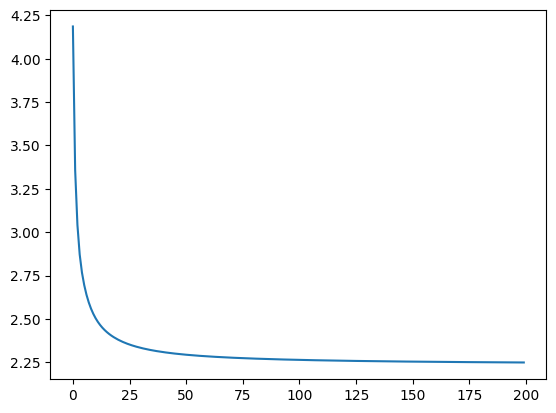

In [17]:
import matplotlib.pyplot as plt
plt.plot(range(len(history)), history)
print("Train loss:", history[-1])

## Hyperparameter tuning

In [18]:
import random
random.seed(1)
random.shuffle(words)
total = len(words)

In [21]:
train, validation, test = words[: int(0.8 * total)], words[int(0.8 * total) : int(0.9 * total)], words[int(0.9 * total)]

trigrams_train, trigrams_validation = extract_trigrams(train), extract_trigrams(validation)
trigram_counts_train = count_tensor_trigrams(train)

In [22]:
history_r = []
history_train_loss = []
history_valid_loss = []

for r in range(1, 100):
  probs = train_statistical_trigram_model(train, trigram_counts=trigram_counts_train, smoothing_rate = r, compute_first_letter = False)
  history_r.append(r)
  history_train_loss.append(trigram_statistical_model_nll_loss(probs, trigrams_train))
  history_valid_loss.append(trigram_statistical_model_nll_loss(probs, trigrams_validation))

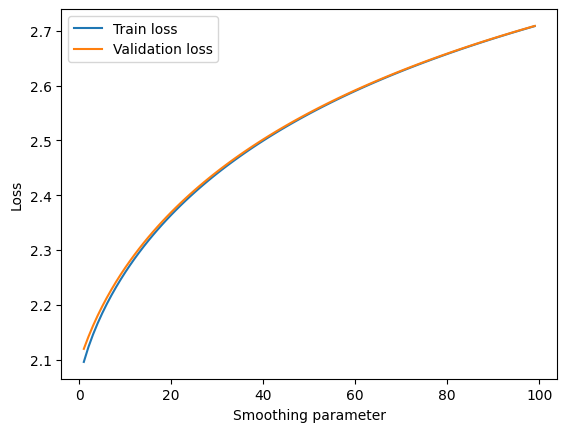

In [23]:
plt.plot(history_r, history_train_loss, label = "Train loss")
plt.plot(history_r, history_valid_loss, label =  "Validation loss")
plt.xlabel("Smoothing parameter")
plt.ylabel("Loss")
plt.legend()

In [24]:
generator = torch.Generator().manual_seed(2147483647)
history_l2_reg = []
history_nn_train_loss = []
history_nn_valid_loss = []

for l2_reg in [0.01, 0.1, 0.5, 1, 2]:
  weights = torch.randn((54, 27), generator=generator, requires_grad=True)
  weights, _ = train_NN_nll_loss(weights, words, n_itter = 200, learning_rate = lambda iterr : 50, l2_reg_coefficent = l2_reg / 10, loss_hist = 0)
  history_l2_reg.append(l2_reg / 10)
  history_nn_train_loss.append(eval_nll(weights, train).item())
  history_nn_valid_loss.append(eval_nll(weights, validation).item())

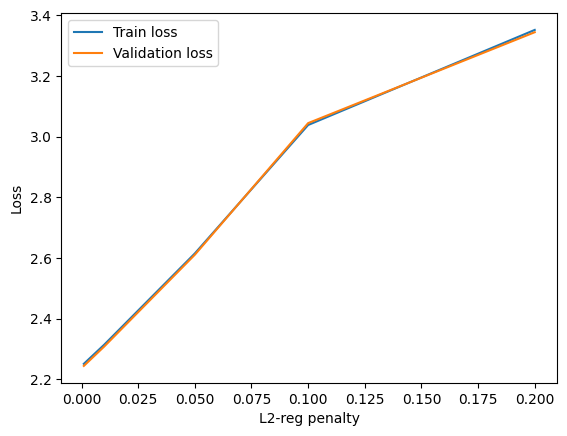

In [25]:
plt.plot(history_l2_reg, history_nn_train_loss, label = "Train loss")
plt.plot(history_l2_reg, history_nn_valid_loss, label =  "Validation loss")
plt.xlabel("L2-reg penalty")
plt.ylabel("Loss")
plt.legend()

## Minor exercises

One can use ``F.cross_entropy`` instead of manually computation softmax + nll and remove one-hot encoding by directly indexing rows of W:

In [99]:
def prepare_dataset_optimized(dataset):
  global alphabet
  trigrams = extract_trigrams(dataset)
  inputs_c1, inputs_c2 = zip(*list(map(lambda trigram: (trigram[0], trigram[1]), trigrams)))
  inputs_c1, inputs_c2 = list(inputs_c1), list(map(lambda x: x+len(alphabet), inputs_c2))
  outputs = torch.tensor(list(map(lambda trigram: trigram[2], trigrams)), requires_grad = False)
  return inputs_c1, inputs_c2, outputs
  
  
def train_NN_nll_loss_optimazied(weights, dataset, n_itter = 100, learning_rate = lambda iterr: 1, l2_reg_coefficent = 0, loss_hist = True):
  # preparing dataset
  inputs_c1, inputs_c2, outputs = prepare_dataset_optimized(dataset)
  history = []
  for iterr in range(1, n_itter + 1):
    # forward pass
    loss = F.cross_entropy(weights[inputs_c1] + weights[inputs_c2], outputs) + l2_reg_coefficent * weights.pow(2).sum().sqrt()
    if loss_hist:
      history.append(loss.item())
    # backward pass
    weights.grad = None
    loss.backward()
    weights.data -= learning_rate(iterr) * weights.grad 
  return weights, history

In [108]:
generator = torch.Generator().manual_seed(2147483647)
weights = torch.randn((54, 27), generator=generator, requires_grad=True)
weights, history = train_NN_nll_loss_optimazied(weights, train, n_itter=200, learning_rate = lambda iterr : 50)

In [109]:
inputs_c1_val, inputs_c2_val, outputs_val = prepare_dataset_optimized(validation)
F.cross_entropy(weights[inputs_c1_val] + weights[inputs_c2_val], outputs_val)

tensor(2.2472, grad_fn=<NllLossBackward0>)